In [1]:
#easter egg :p
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
spy = yf.download("SPY", start="1993-01-01")


prices = spy["Close"]
daily_returns = prices.pct_change()


#cumprod returns cumulative_product
#always vectorize

cumulative_returns = (1 + daily_returns).cumprod() - 1
    #  (100% + x).cumprod()


#spy.head()
daily_returns.head()
cumulative_returns.head()

[*********************100%***********************]  1 of 1 completed


Ticker,SPY
Date,
1993-01-29,NaN
1993-02-01,0.007113
1993-02-02,0.009246
1993-02-03,0.019915
1993-02-04,0.024182


In [3]:
rolling_peak = prices.cummax()
drawdown = prices / rolling_peak - 1
drawdown.head()
print(drawdown.min())

equity_curve = (1 + daily_returns).cumprod() 

Ticker
SPY   -0.551894
dtype: float64


<Figure size 1200x600 with 0 Axes>

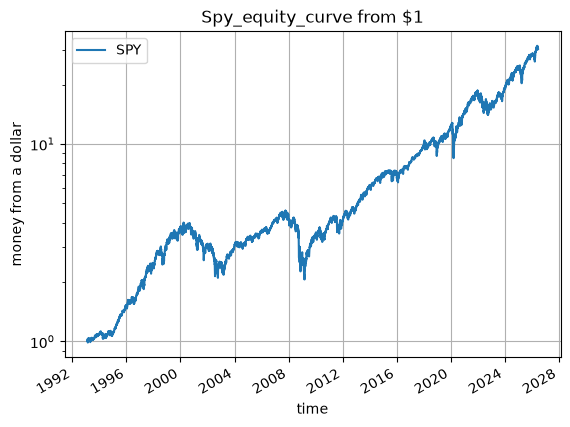

In [4]:
plt.figure(figsize = (12,6))
equity_curve.plot(label = "spy equity curve")
plt.title("Spy_equity_curve from $1")
plt.xlabel("time")
plt.ylabel("money from a dollar")
plt.grid(True)
plt.yscale("log")
plt.legend()

<Axes: xlabel='Date'>

<Figure size 640x480 with 0 Axes>

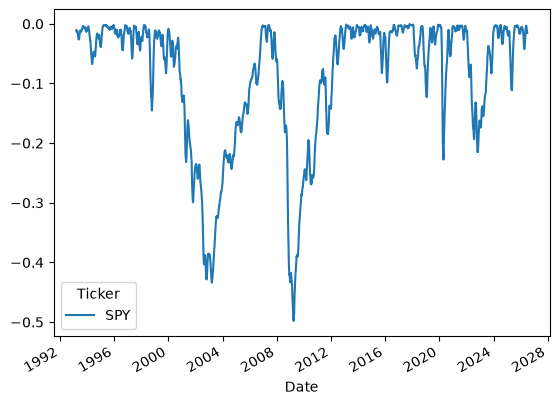

In [5]:
# plt.figure()
# drawdown.plot(label = "drawdown")
# plt.title("Drawdown Plot")
# plt.xlabel("time")
# plt.ylabel("curr drop from max")
# plt.grid(True)
# plt.legend()

#interesting plot: to make smooth, using rolling(window = x)


smoothed_drawdown = drawdown.rolling(window=30).mean()

plt.figure()
smoothed_drawdown.plot(label = "smoothed_darwodnw0")

In [6]:
total_return = equity_curve.iloc[-1]

years = len(daily_returns.dropna()) / 252

cagr = total_return ** (1 / years) - 1


#standard deviation of yearly returns
annualized_volatility = np.sqrt(252) * daily_returns.std()

sharpe_ratio = daily_returns.mean() / daily_returns.std() * np.sqrt(252)

max_drawdown = drawdown.min()

In [7]:
summary_stats = pd.Series({
    "CAGR": cagr,
    "Annualized Volatility": annualized_volatility,
    "Sharpe Ratio": sharpe_ratio,
    "Max Drawdown": max_drawdown
})

summary_stats

CAGR                     Ticker
SPY    0.107686
Name: 2026-06-26 00:00:...
Annualized Volatility                Ticker
SPY    0.185747
dtype: float64
Sharpe Ratio                         Ticker
SPY    0.643631
dtype: float64
Max Drawdown                         Ticker
SPY   -0.551894
dtype: float64
dtype: object

In [8]:
depth = -0.05
length = 21 #if it goes down 5% in the last 21 days, we buy
hold = 21 #and then we hold it for 21 days

In [9]:
#there is only invested and not invested.

In [10]:
rolling_peak = prices.rolling(21).max()
rolling_drawdown = prices / rolling_peak - 1
buy_signal = rolling_drawdown <= depth #boolean list

position = buy_signal.rolling(hold).max() #1 if buy_signal is 1 in the past 'hold' days
position = position.fillna(0) #else 0

position = position.shift(1).fillna(0) #no cheating
strategy_returns = position * daily_returns
btd_equity_curve = (1 + strategy_returns).cumprod()

Text(0, 0.5, 'money change')

<Figure size 640x480 with 0 Axes>

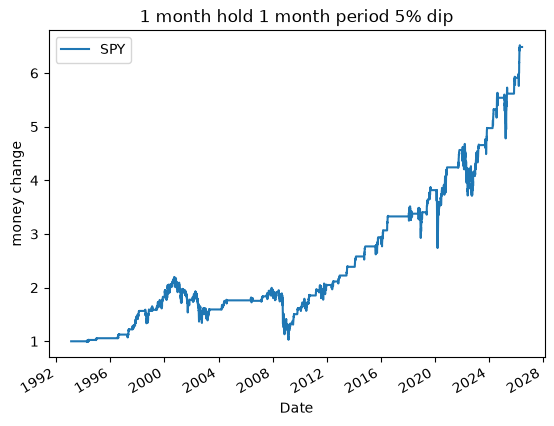

In [11]:
plt.figure()
btd_equity_curve.plot(label="SPY")
plt.title("1 month hold 1 month period 5% dip")
plt.legend()
plt.ylabel("money change")

In [12]:
#note how it's pretty bad here. that's what we expected

equity_curve = equity_curve.squeeze()
btd_equity_curve = btd_equity_curve.squeeze()

In [13]:
#comparing the two:
comparison = pd.DataFrame({
    "Buy and hold" : equity_curve,
    "BTD, 5%, month, month" : btd_equity_curve
})

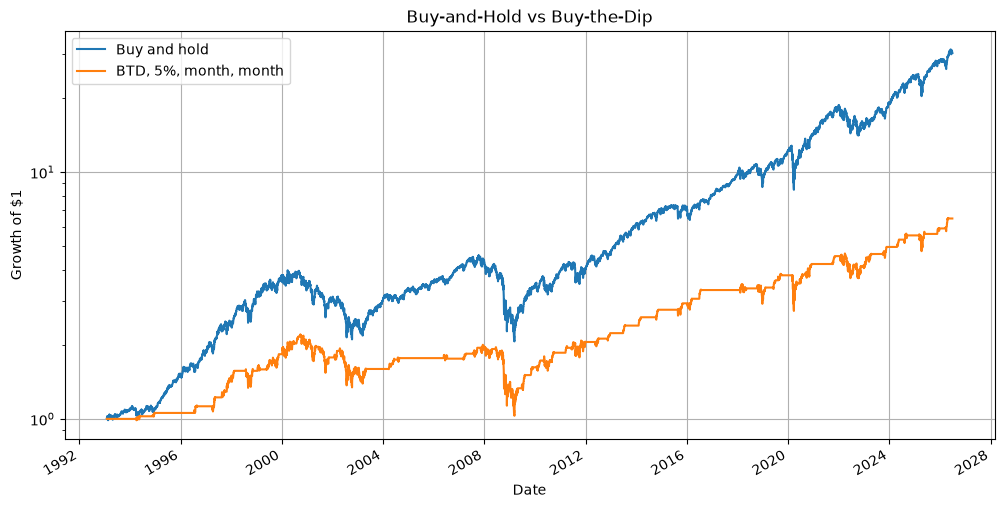

In [14]:
comparison.plot(figsize=(12, 6), logy=True)
plt.title("Buy-and-Hold vs Buy-the-Dip")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

In [15]:
btd_equity_curve = btd_equity_curve.squeeze()
equity_curve = equity_curve.squeeze()
daily_returns = daily_returns.squeeze()
strategy_returns = strategy_returns.squeeze()
drawdown = drawdown.squeeze()

years = len(daily_returns.dropna()) / 252

buy_hold_total_return = equity_curve.iloc[-1]
buy_hold_cagr = buy_hold_total_return ** (1 / years) - 1
buy_hold_vol = daily_returns.std() * np.sqrt(252)
buy_hold_sharpe = daily_returns.mean() / daily_returns.std() * np.sqrt(252)
buy_hold_max_drawdown = drawdown.min()



In [16]:
btd_total_return = btd_equity_curve.iloc[-1]
btd_cagr = btd_total_return ** (1 / years) - 1
btd_vol = strategy_returns.std() * np.sqrt(252)
btd_sharpe = strategy_returns.mean() / strategy_returns.std() * np.sqrt(252)

btd_drawdown = btd_equity_curve / btd_equity_curve.cummax() - 1
btd_max_drawdown = btd_drawdown.min()


In [17]:
summary_table = pd.DataFrame({
    "Buy and Hold": [
        buy_hold_cagr,
        buy_hold_vol,
        buy_hold_sharpe,
        buy_hold_max_drawdown
    ],
    "BTD -5%, 1M lookback, 1M hold": [
        btd_cagr,
        btd_vol,
        btd_sharpe,
        btd_max_drawdown
    ]
}, index=[
    "CAGR",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Max Drawdown"
])

summary_table

,Buy and Hold,"BTD -5%, 1M lookback, 1M hold"
CAGR,0.107686,0.057631
Annualized Volatility,0.185747,0.155510
Sharpe Ratio,0.643631,0.438022
Max Drawdown,-0.551894,-0.531487


In [18]:
def run_btd_strategy(prices, daily_returns, depth, lookback=21, hold=21):
    prices = prices.squeeze()
    daily_returns = daily_returns.squeeze() #squeeze from df to series

    rolling_peak = prices.rolling(lookback).max()
    rolling_drawdown = prices / rolling_peak - 1

    buy_signal = rolling_drawdown <= depth

    position = buy_signal.rolling(hold).max()
    position = position.fillna(0)
    position = position.shift(1).fillna(0)


    strategy_returns = position * daily_returns
    strategy_returns = strategy_returns.fillna(0)

    equity_curve = (1 + strategy_returns).cumprod()

    return strategy_returns, equity_curve

    

In [19]:
btd_5_returns, btd_5_equity = run_btd_strategy(
    prices,
    daily_returns,
    depth=-0.05,
    lookback=21,
    hold=21
)

btd_10_returns, btd_10_equity = run_btd_strategy(
    prices,
    daily_returns,
    depth=-0.10,
    lookback=21,
    hold=21
)

btd_20_returns, btd_20_equity = run_btd_strategy(
    prices,
    daily_returns,
    depth=-0.20,
    lookback=21,
    hold=21
)

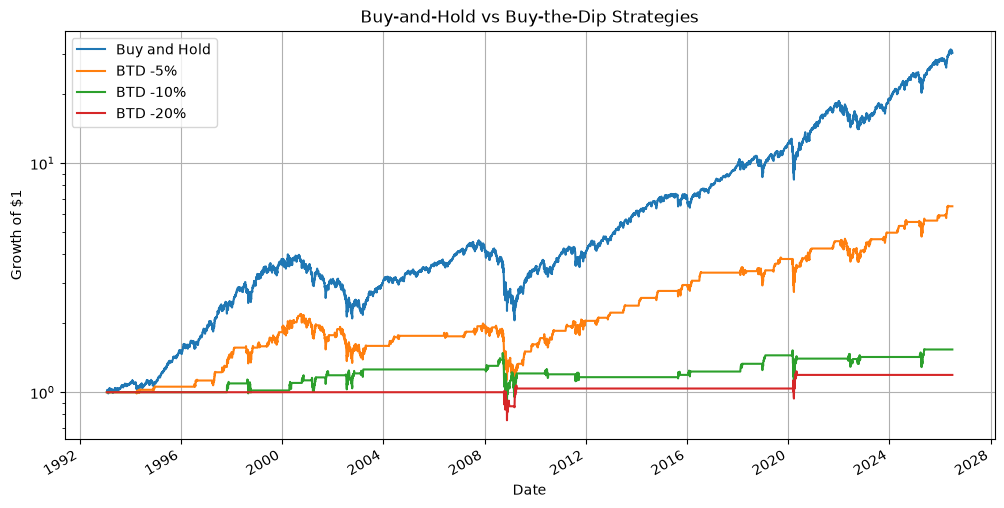

In [20]:
equity_comparison = pd.DataFrame({
    "Buy and Hold": equity_curve.squeeze(),
    "BTD -5%": btd_5_equity.squeeze(),
    "BTD -10%": btd_10_equity.squeeze(),
    "BTD -20%": btd_20_equity.squeeze()
})

equity_comparison.plot(figsize=(12, 6), logy=True)
plt.title("Buy-and-Hold vs Buy-the-Dip Strategies")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()